<a href="https://colab.research.google.com/github/Epsilon-Yuan/HCP-project/blob/main/NMA_project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NMA Project

Based on [this paper](https://journals.sagepub.com/doi/10.1089/brain.2020.0968?url_ver=Z39.88-2003&rfr_id=ori:rid:crossref.org&rfr_dat=cr_pub%20%200pubmed).

[Excalidraw](https://excalidraw.com/#room=50ee5b77a817d5e18246,sI9x_j2P3w6bxQ_p_txb5w)

[Abstract](https://docs.google.com/document/d/17EOFEvNznhZzG8QKbHklh2ye6Y4Ua_htzP4eIh4KDIU/edit?tab=t.0)
## Overview
**Step 1**

1. What is our question/phenomenon?

Can the functional connectome work as a fingerprint to identify a person?

2. What exact aspect of our question needs modelling?

Fingerprint: functional connectivity matrix (Pearson-correlation coefficients between all 360 regions)

Identifiability: the mathematical relationship between the predictor FC matrix and the outcome FC matrix

3. How do we evaluate the success of our model? Can we compare our outcomes to other data?

Use the differential idenfiability calculation in the paper above, where we create a new correlation matrix between a given participants recording within one task condition (2 conditions/task) with everyone's (the same participant + all other participants) in the second task condition. We expect the individual to correlate with themselves (higher Pearson correlation coefficient in the matrix diagonal) more than others (off-diagonal).

**Step 2**
1. What ingredients do we need?

360x360 correlation matrix (360 brain regions BOLD signal correlation with each other) for 100 participants.

2. What variables from the data should we extract?

Processed BOLD signals transformed into:
Baseline (raw) FC matrix -> Absolute FC (same as baseline FC but with absolute numbers) -> Normalised FC matrix

3. What methods should we apply to them?

Vectorize the upper triangle of the normalised FC -> create 100 subsamples (80% of original dataset each time)

For each subsample:
conduct PCA -> reconstruct FCs -> construct identifiability matrix -> compute each metric

**Step 3**
1. What is our hypothesis (verbal)?

Task-based FC is more similar within an individual across session than between individuals.

2. What is our primary mathematical hypothesis? (using the basic ingredients we defined above)

FC of indiviual i in condition A

---

## Mathematical steps to be implemented



# Load HCP parcellated task data - Provided by Neuromatch
## (version with Behavioural Data)

-----------------------------------------------------------------------------

Derived from the provided [Neuromatch Colab](https://colab.research.google.com/github/NeuromatchAcademy/course-content/blob/main/projects/fMRI/load_hcp_task_with_behaviour.ipynb#scrollTo=ime9wghJLH_-)  

-----------------------------------------------------------------------------
The HCP dataset comprises task-based fMRI from a large sample of human subjects. The NMA-curated dataset includes time series data that has been preprocessed and spatially-downsampled by aggregating within 360 regions of interest.

In order to use this dataset, please electronically sign the HCP data use terms at [ConnectomeDB](https://db.humanconnectome.org). Instructions for this are on pp. 24-25 of the [HCP Reference Manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

In this notebook, NMA provides code for downloading the data and doing some basic visualisation and processing.

7 cognitive domains measured with fMRI recordings

# LIBRARIES & DEPENDENCIES

In [ ]:
!pip install nilearn --quiet

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
#@title Figure settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [ ]:
# The data shared for NMA projects is a subset of the full HCP dataset
N_SUBJECTS = 100

# The data have already been aggregated into ROIs from the Glasser parcellation
N_PARCELS = 360

# The acquisition parameters for all tasks were identical
TR = 0.72  # Time resolution, in seconds

# The parcels are matched across hemispheres with the same order
HEMIS = ["Right", "Left"]

# Each experiment was repeated twice in each subject
RUNS   = ['LR','RL']
N_RUNS = 2

# There are 7 tasks. Each has a number of 'conditions'
# TIP: look inside the data folders for more fine-graned conditions

EXPERIMENTS = {
    'MOTOR'      : {'cond':['lf','rf','lh','rh','t','cue']},
    'WM'         : {'cond':['0bk_body','0bk_faces','0bk_places','0bk_tools','2bk_body','2bk_faces','2bk_places','2bk_tools']},
    'EMOTION'    : {'cond':['fear','neut']},
    'GAMBLING'   : {'cond':['loss','win']},
    'LANGUAGE'   : {'cond':['math','story']},
    'RELATIONAL' : {'cond':['match','relation']},
    'SOCIAL'     : {'cond':['ment','rnd']}
}

> For a detailed description of the tasks have a look pages 45-54 of the [HCP reference manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

# Download the data needed for the analysis

In [ ]:
# @title Download data file
import os, requests

fname = "hcp_task.tgz"
url = "https://osf.io/2y3fw/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [ ]:
# The download cells will store the data in nested directories starting here:
HCP_DIR = "./hcp_task"

# importing the "tarfile" module
import tarfile

# open file
with tarfile.open(fname) as tfile:
  # extracting file
  tfile.extractall('.')

subjects = np.loadtxt(os.path.join(HCP_DIR, 'subjects_list.txt'), dtype='str')

/tmp/ipykernel_4450/2825554391.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall('.')


## Understanding the folder organisation

The data folder has the following organisation:

- hcp
  - regions.npy (information on the brain parcellation)
  - subjects_list.txt (list of subject IDs)
  - subjects (main data folder)
    - [subjectID] (subject-specific subfolder)
      - EXPERIMENT (one folder per experiment)
        - RUN (one folder per run)
          - data.npy (the parcellated time series data)
          - EVs (EVs folder)
            - [ev1.txt] (one file per condition)
            - [ev2.txt]
            - Stats.txt (behavioural data [where available] - averaged per run)
            - Sync.txt (ignore this file)



## Loading region information

Downloading this dataset will create the `regions.npy` file, which contains the region name and network assignment for each parcel.

Detailed information about the name used for each region is provided [in the Supplement](https://static-content.springer.com/esm/art%3A10.1038%2Fnature18933/MediaObjects/41586_2016_BFnature18933_MOESM330_ESM.pdf) to [Glasser et al. 2016](https://www.nature.com/articles/nature18933).

Information about the network parcellation is provided in [Ji et al, 2019](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6289683/).



In [ ]:
regions = np.load(f"{HCP_DIR}/regions.npy").T
region_info = dict(
    name=regions[0].tolist(),
    network=regions[1],
    hemi=['Right']*int(N_PARCELS/2) + ['Left']*int(N_PARCELS/2),
)

# Help functions

We provide two helper functions: one for loading the time series from a single suject and a single run, and one for loading an EV file for each task.

An EV file (EV:Explanatory Variable) describes the task experiment in terms of stimulus onset, duration, and amplitude. These can be used to model the task time series data.

In [ ]:
def load_single_timeseries(subject, experiment, run, remove_mean=True):
  """Load timeseries data for a single subject and single run.

  Args:
    subject (str):      subject ID to load
    experiment (str):   Name of experiment
    run (int):          (0 or 1)
    remove_mean (bool): If True, subtract the parcel-wise mean (typically the mean BOLD signal is not of interest)

  Returns
    ts (n_parcel x n_timepoint array): Array of BOLD data values

  """
  bold_run  = RUNS[run]
  bold_path = f"{HCP_DIR}/subjects/{subject}/{experiment}/tfMRI_{experiment}_{bold_run}"
  bold_file = "data.npy"
  ts = np.load(f"{bold_path}/{bold_file}")
  if remove_mean:
    ts -= ts.mean(axis=1, keepdims=True)
  return ts


def load_evs(subject, experiment, run):
  """Load EVs (explanatory variables) data for one task experiment.

  Args:
    subject (str): subject ID to load
    experiment (str) : Name of experiment
    run (int): 0 or 1

  Returns
    evs (list of lists): A list of frames associated with each condition

  """
  frames_list = []
  task_key = f'tfMRI_{experiment}_{RUNS[run]}'
  for cond in EXPERIMENTS[experiment]['cond']:
    ev_file  = f"{HCP_DIR}/subjects/{subject}/{experiment}/{task_key}/EVs/{cond}.txt"
    ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
    ev       = dict(zip(["onset", "duration", "amplitude"], ev_array))
    # Determine when trial starts, rounded down
    start = np.floor(ev["onset"] / TR).astype(int)
    # Use trial duration to determine how many frames to include for trial
    duration = np.ceil(ev["duration"] / TR).astype(int)
    # Take the range of frames that correspond to this specific trial
    frames = [s + np.arange(0, d) for s, d in zip(start, duration)]
    frames_list.append(frames)

  return frames_list

# Example run - load and visualize data

In [ ]:
my_exp = 'MOTOR'
my_subj = subjects[1]
my_run = 1

data = load_single_timeseries(subject=my_subj,
                              experiment=my_exp,
                              run=my_run,
                              remove_mean=True)
print(data.shape)

(360, 284)


As you can see the time series data contains 284 time points in 360 regions of interest (ROIs).



Now in order to understand how to model these data, we need to relate the time series to the experimental manipulation. This is described by the EV files. Let us load the EVs for this experiment.

In [ ]:
evs = load_evs(subject=my_subj, experiment=my_exp, run=my_run)

For the motor task, this evs variable contains a list of 5 arrays corresponding to the 5 conditions.

Now let's use these evs to compare the average activity during the left foot ('lf') and right foot ('rf') conditions:

In [ ]:
# we need a little function that averages all frames from any given condition
def average_frames(data, evs, experiment, cond):
  idx = EXPERIMENTS[experiment]['cond'].index(cond)
  return np.mean(np.concatenate([np.mean(data[:, evs[idx][i]], axis=1, keepdims=True) for i in range(len(evs[idx]))], axis=-1), axis=1)


lf_activity = average_frames(data, evs, my_exp, 'lf')
rf_activity = average_frames(data, evs, my_exp, 'rf')
contrast = lf_activity - rf_activity  # difference between left and right hand movement


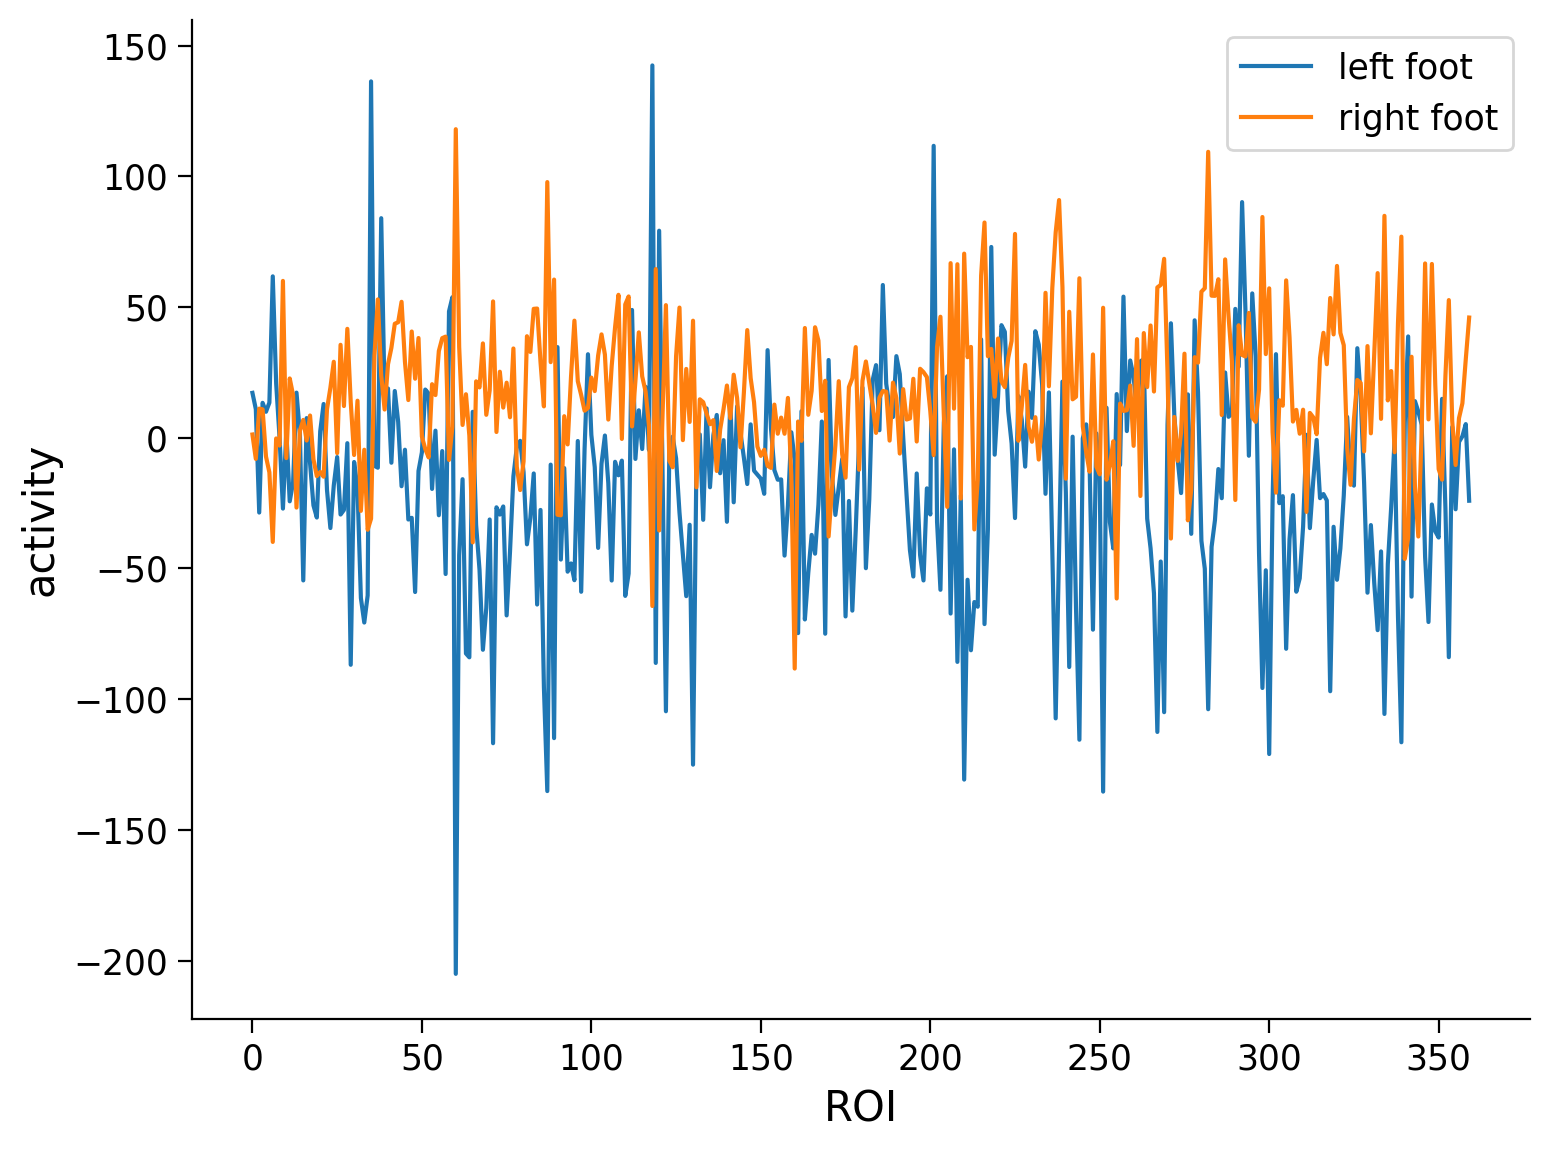

In [ ]:
# Plot activity level in each ROI for both conditions
plt.plot(lf_activity,label='left foot')
plt.plot(rf_activity,label='right foot')
plt.xlabel('ROI')
plt.ylabel('activity')
plt.legend()
plt.show()

Now let's plot these activity vectors. We will also make use of the ROI names to find out which brain areas show highest activity in these conditions. But since there are so many areas, we will group them by network.

A powerful tool for organising and plotting this data is the combination of pandas and seaborn. Below is an example where we use pandas to create a table for the activity data and we use seaborn oto visualise it.





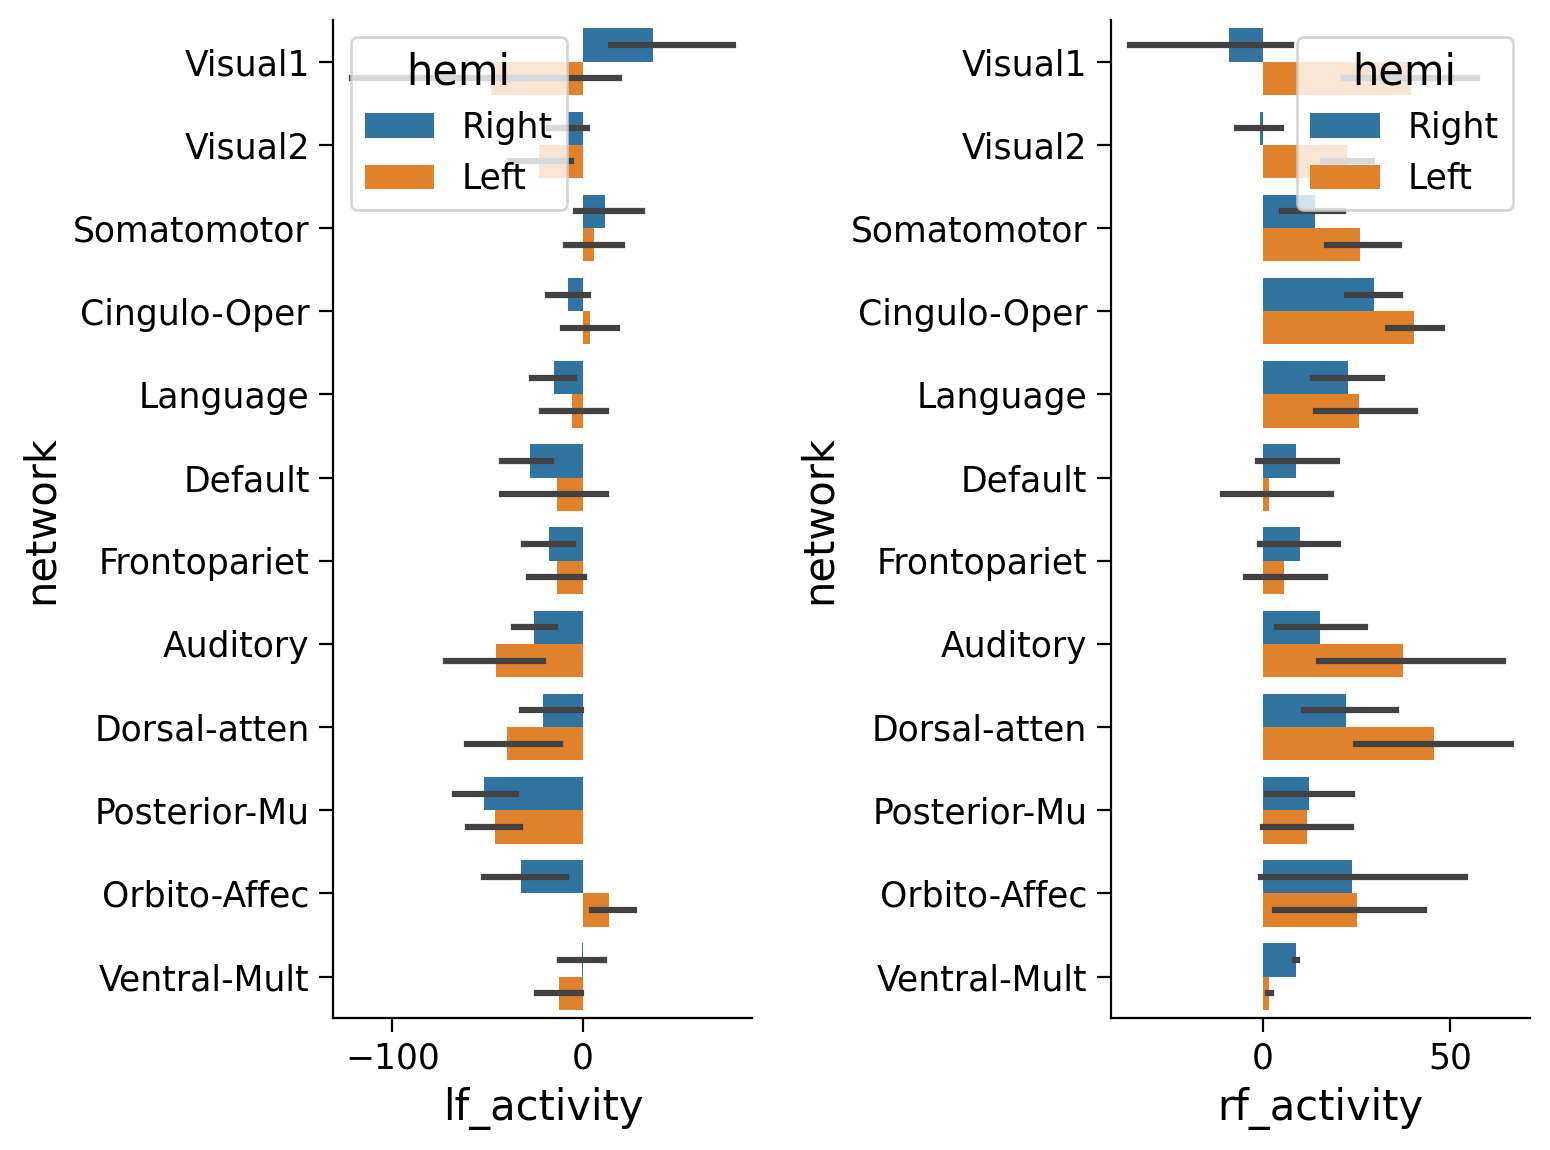

In [ ]:
df = pd.DataFrame({'lf_activity' : lf_activity,
                   'rf_activity' : rf_activity,
                   'network' : region_info['network'],
                   'hemi' : region_info['hemi']})

fig, (ax1, ax2) = plt.subplots(1, 2)
sns.barplot(y='network', x='lf_activity', data=df, hue='hemi',ax=ax1)
sns.barplot(y='network', x='rf_activity', data=df, hue='hemi',ax=ax2)
plt.show()

You should be able to notice that for the somatosensory network, brain activity in the right hemi is higher for the left foot movement and vice versa for the left hemi and right foot. But this may be subtle at the single subject/session level (these are quick 3-4min scans).


Let us boost thee stats by averaging across all subjects and runs.

In [ ]:
group_contrast = 0
for s in subjects:
  for r in [0, 1]:
    data = load_single_timeseries(subject=s, experiment=my_exp,
                                  run=r, remove_mean=True)
    evs = load_evs(subject=s, experiment=my_exp,run=r)

    lf_activity = average_frames(data, evs, my_exp, 'lf')
    rf_activity = average_frames(data, evs, my_exp, 'rf')

    contrast = lf_activity - rf_activity
    group_contrast += contrast

group_contrast /= (len(subjects)*2)  # remember: 2 sessions per subject

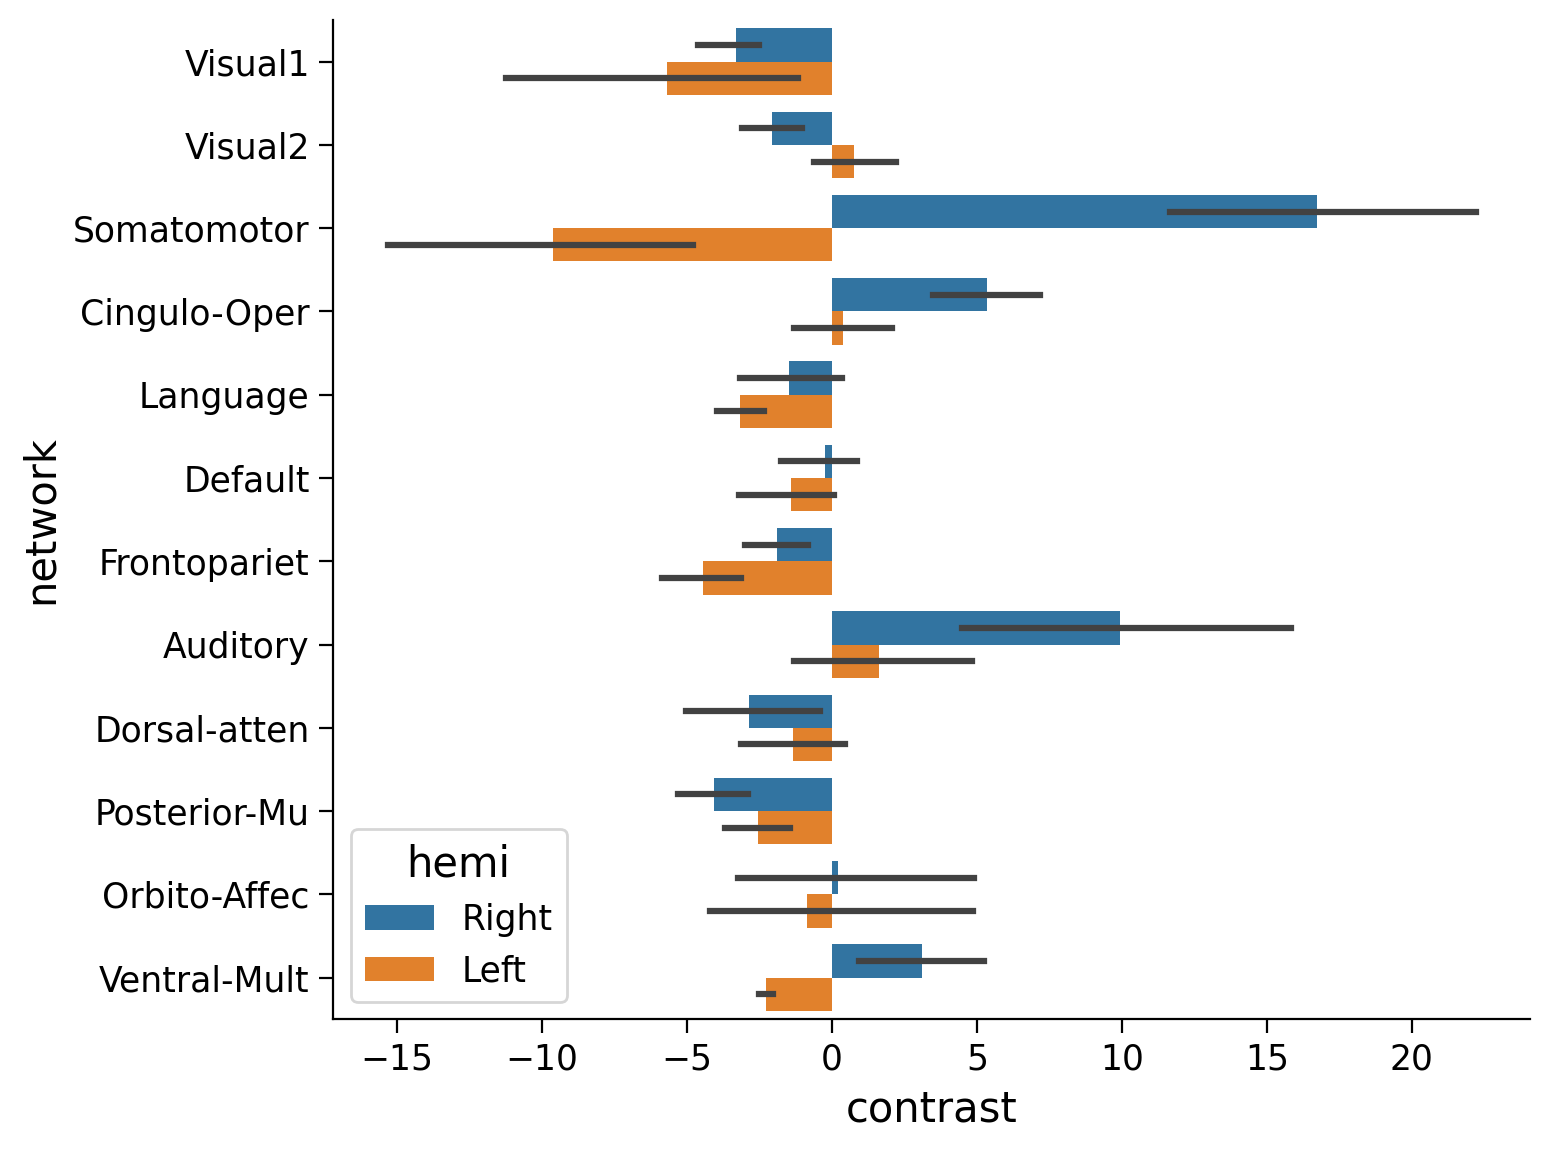

In [ ]:
df = pd.DataFrame({'contrast' : group_contrast,
                   'network' : region_info['network'],
                   'hemi' : region_info['hemi']
                   })
# we will plot the left foot minus right foot contrast so we only need one plot
plt.figure()
sns.barplot(y='network', x='contrast', data=df, hue='hemi')
plt.show()

# Visualising the results on a brain

Finally, we will visualise these results on the cortical surface of an average brain.

In [ ]:
# @title NMA provides an atlas. Run this cell to download it
import os, requests

# NMA provides an atlas
fname = f"{HCP_DIR}/atlas.npz"
url = "https://osf.io/j5kuc/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

with np.load(fname) as dobj:
  atlas = dict(**dobj)

In [ ]:
# This uses the nilearn package
from nilearn import plotting, datasets

# Try both hemispheres (L->R and left->right)
fsaverage = datasets.fetch_surf_fsaverage()
surf_contrast = group_contrast[atlas["labels_L"]]
plotting.view_surf(fsaverage['infl_left'],
                   surf_contrast,
                   vmax=20)

# MAIN PART OF PROJECT CODE

In [ ]:
# The data shared for NMA projects is a subset of the full HCP dataset
N_SUBJECTS = 100

# The data have already been aggregated into ROIs from the Glasser parcellation
N_PARCELS = 360

# The acquisition parameters for all tasks were identical
TR = 0.72  # Time resolution, in seconds

# The parcels are matched across hemispheres with the same order
HEMIS = ["Right", "Left"]

# Each experiment was repeated twice in each subject
RUNS   = ['LR','RL']
N_RUNS = 2

# There are 7 tasks. Each has a number of 'conditions'
# TIP: look inside the data folders for more fine-graned conditions

EXPERIMENTS = {
    'MOTOR'      : {'cond':['lf','rf','lh','rh','t','cue']},
    'WM'         : {'cond':['0bk_body','0bk_faces','0bk_places','0bk_tools','2bk_body','2bk_faces','2bk_places','2bk_tools']},
    'EMOTION'    : {'cond':['fear','neut']},
    'GAMBLING'   : {'cond':['loss','win']},
    'LANGUAGE'   : {'cond':['math','story']},
    'RELATIONAL' : {'cond':['match','relation']},
    'SOCIAL'     : {'cond':['ment','rnd']}
}

# Data Structure & Dimensions

For the fMRI data analysis, we utilize the specifications provided by the official **[Human Connectome Project (HCP) Reference Manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf)** . Each task features a specific number of time points (Frames per run) and duration:

| Task | Runs | Frames per run | Run Duration (min:sec) |
| :--- | :---: | :---: | :---: |
| **Working Memory** | 2 | 405 | 5:01 |
| **Gambling** | 2 | 253 | 3:12 |
| **Motor** | 2 | 284 | 3:34 |
| **Language** | 2 | 316 | 3:57 |
| **Social Cognition** | 2 | 274 | 3:27 |
| **Relational Processing** | 2 | 232 | 2:56 |
| **Emotion Processing** | 2 | 176 | 2:16 |

---

## 3D Data Representation (Per Task)

To efficiently store and access the dataset, we propose a **3D structure (Array/Tensor)** for each individual task. The dimensions of the array are structured as follows:

* **1D (First Dimension):** Number of Participants $\rightarrow$ **100**
* **2D (Second Dimension):** Number of Time Points (Frames) $\rightarrow$ **Varies by Task** (e.g., 284 for Motor, 405 for Working Memory)
* **3D (Third Dimension):** Number of Regions of Interest (ROIs) $\rightarrow$ **360**

### Data Volume Example (Motor Task):
> **Total Data Points (Motor):** $100 \times 284 \times 360 = 10,224,000$ values per run.

Given the exceptionally large volume of data and high dimensionality, employing dimensionality reduction techniques such as **Principal Component Analysis (PCA)** is crucial before proceeding with the extraction of Functional Connectivity (FC) fingerprints.

---

## Task Data Variables

Each variable below will store the corresponding 3D data structure for each task, using its respective number of frames/time points:

* `data_wm` (Frames: 405)
* `data_gambling` (Frames: 253)
* `data_motor` (Frames: 284)
* `data_language` (Frames: 316)
* `data_social` (Frames: 274)
* `data_relational` (Frames: 232)
* `data_emotion` (Frames: 176)

## Motor Task

(Trenyce): write a for-loop that creates separate dataframes for each task

In [ ]:
# Define task timepoints derived from the HCP document
task_timepoints = {
    'MOTOR': 284,
    'WM': 405,
    'GAMBLING': 253,
    'LANGUAGE': 316,
    'SOCIAL': 274,
    'RELATIONAL': 232,
    'EMOTION': 176
}

# Dictionary to store data for Run 0 (LR) for all tasks
task_data_run0 = {}
task_data_run1 = {}

for experiment, timepoints in task_timepoints.items():

  #task_timepoints.items() --> dict_items([('MOTOR', 284), ('WM', 405), ('GAMBLING', 253),
  # ('LANGUAGE', 316), ('SOCIAL', 274), ('RELATIONAL', 232), ('EMOTION', 176)])

    # Initialize 3D array: (Subjects, Regions, Timepoints)
    task_data_run0[experiment] = np.empty((N_SUBJECTS, N_PARCELS, timepoints))
    task_data_run1[experiment] = np.empty((N_SUBJECTS, N_PARCELS, timepoints))

    for i in range(N_SUBJECTS):

       # 1st run
        task_data_run0[experiment][i] = load_single_timeseries(subject=subjects[i],
                                                        experiment=experiment,
                                                        run=0,
                                                        remove_mean=True)
        # 2nd run
        task_data_run1[experiment][i] = load_single_timeseries(subject = subjects[i],
                                                               experiment = experiment,
                                                               run = 1,
                                                               remove_mean = True)

# Verification
for exp, data in task_data_run0.items():
    print(f"{exp}| shape: {data.shape} | dtype: {data.dtype}")

MOTOR| shape: (100, 360, 284) | dtype: float64
WM| shape: (100, 360, 405) | dtype: float64
GAMBLING| shape: (100, 360, 253) | dtype: float64
LANGUAGE| shape: (100, 360, 316) | dtype: float64
SOCIAL| shape: (100, 360, 274) | dtype: float64
RELATIONAL| shape: (100, 360, 232) | dtype: float64
EMOTION| shape: (100, 360, 176) | dtype: float64


In [ ]:

bold_signals = task_data_run0['MOTOR'][0]


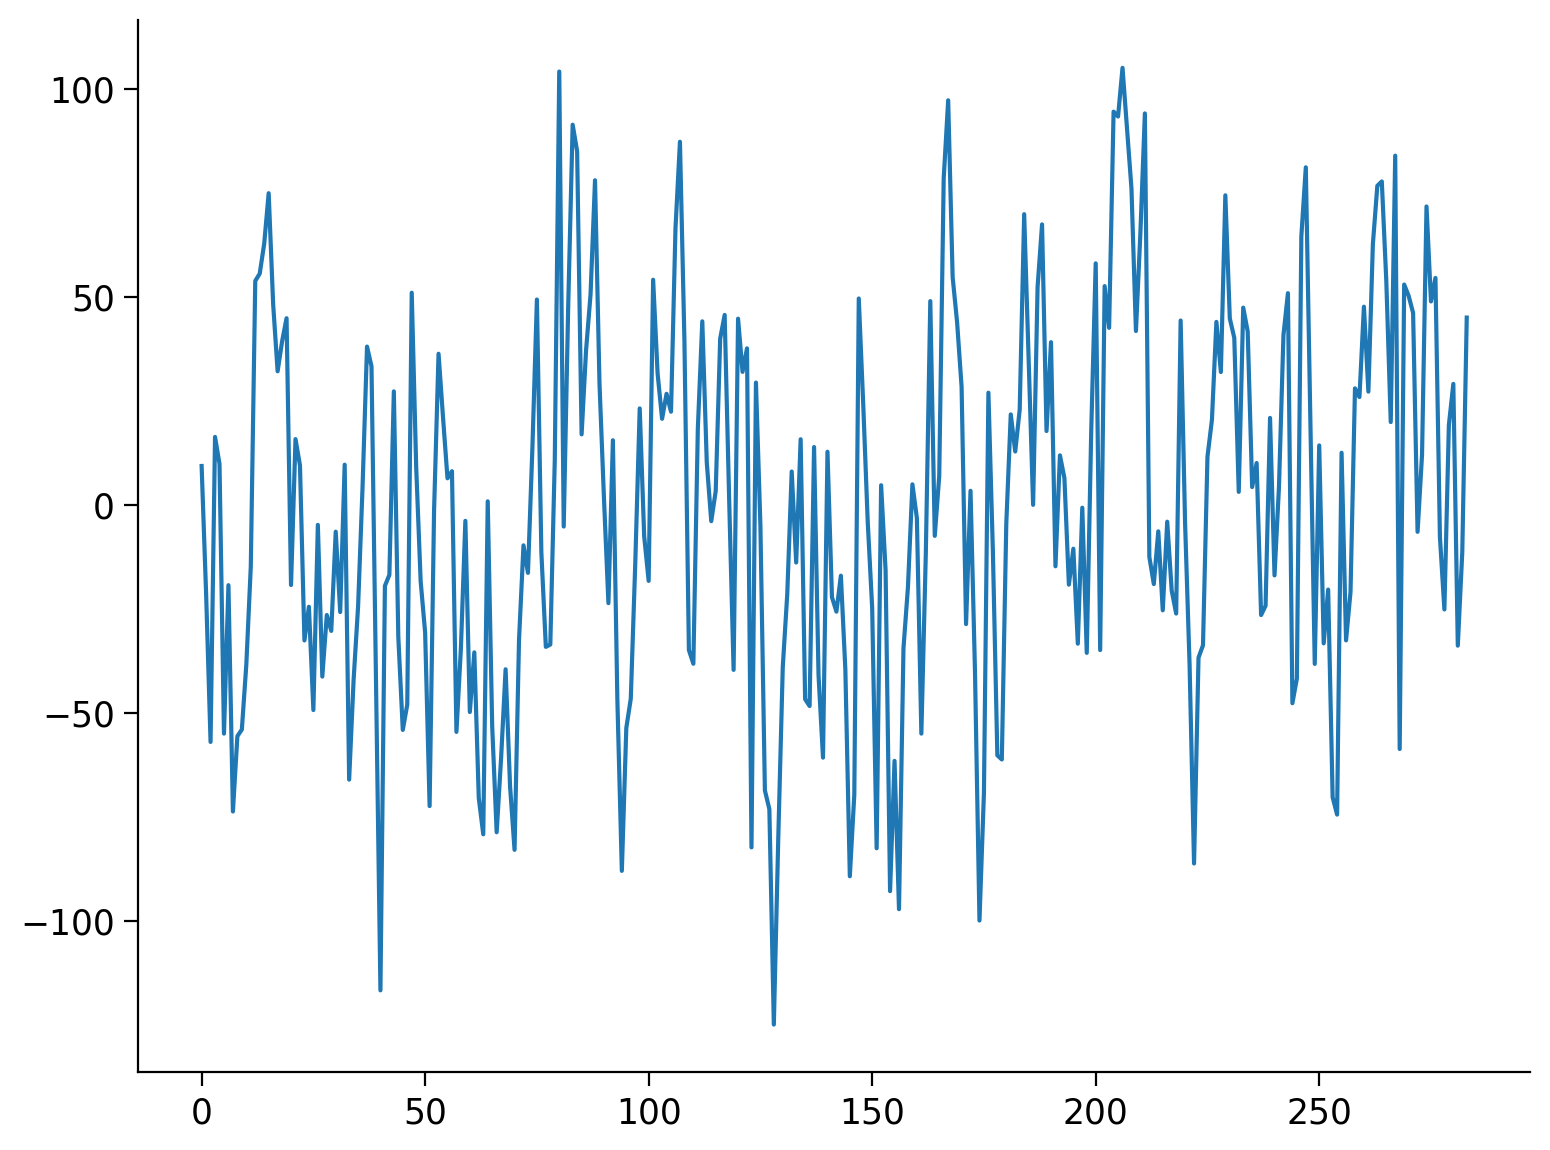

In [ ]:
plt.plot(bold_signals[1])

## How to refer/acess to specific task

Take 'MOTOR' experiment as an example. If we run the following command :

task_data_run0['MOTOR'].shape ---> (100,360,284)

What this means --> For the motor experiment we have 100 participants, for each participant we have 360 ROIs and for each ROIs we have a signal that is equal to 284 time points.



In [ ]:
task_data_run0['MOTOR'].shape

(100, 360, 284)

## Referencing a Specific Participant

Let's look at the motor experiment again. To reference the first participant (index `0`), we use the following command:

```python
# Extract BOLD signals for the first participant (index 0)
bold_signals_participant1 = task_data_run0['MOTOR'][0]

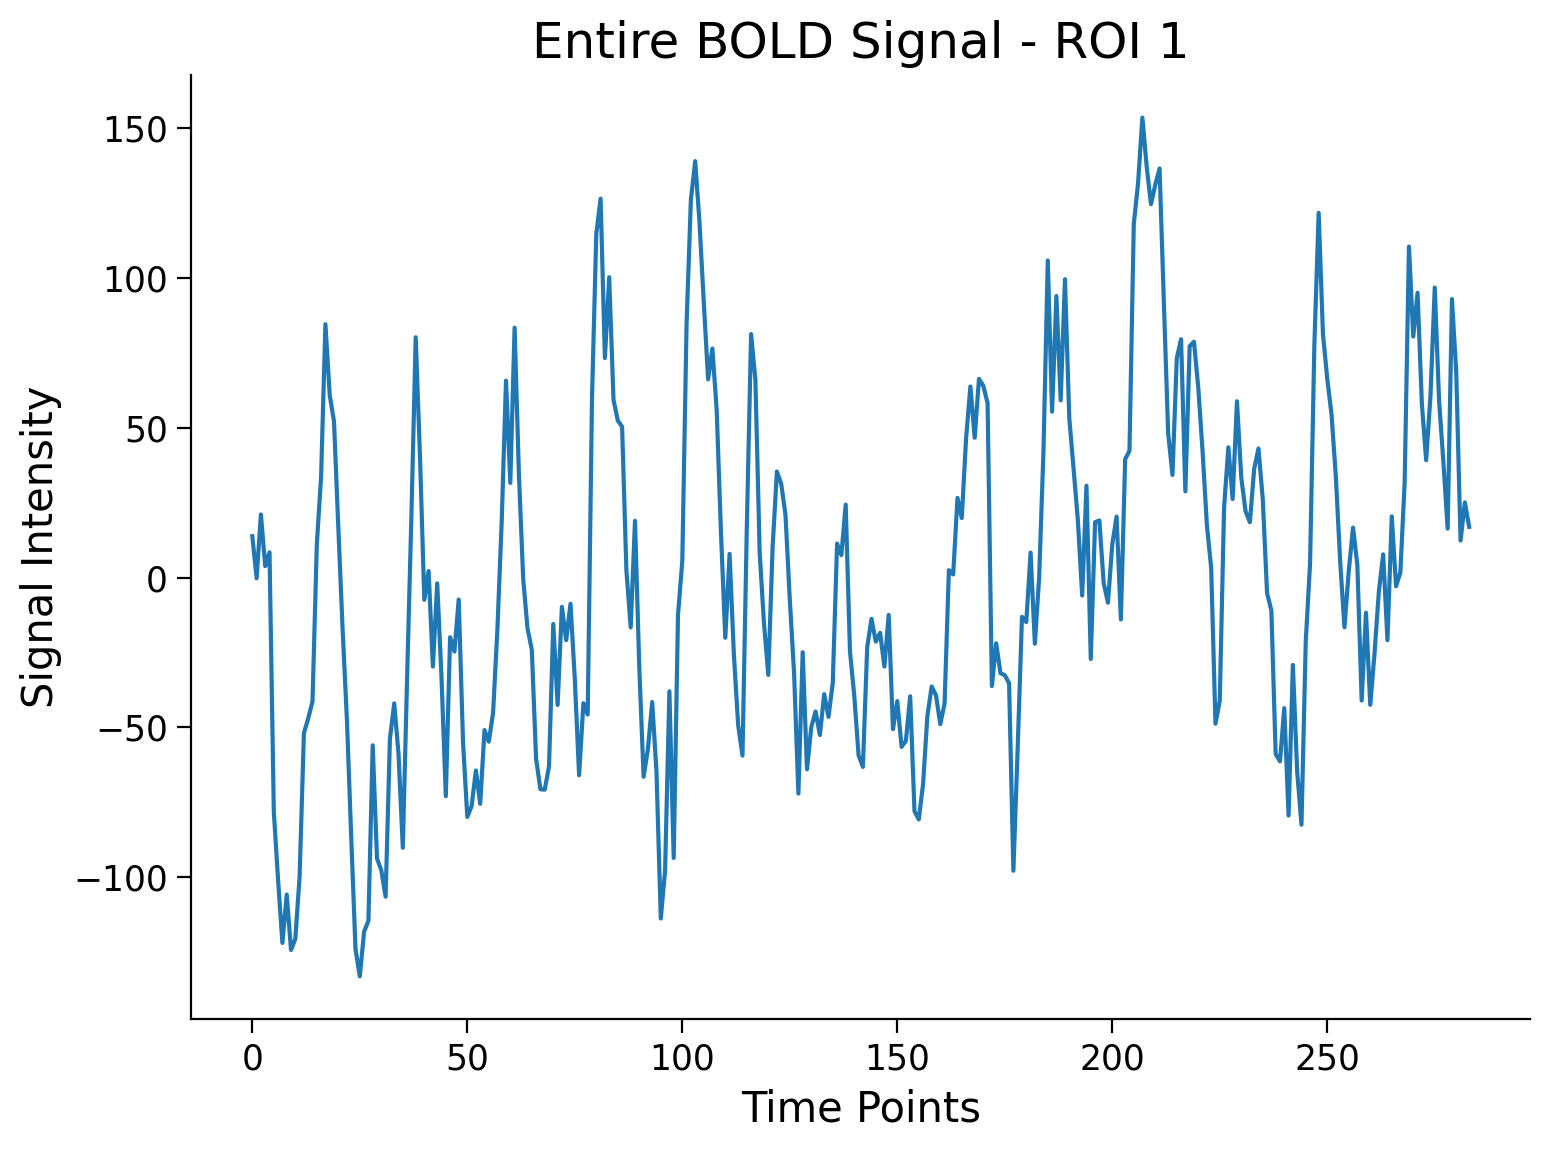

In [ ]:
bold_signals_participant1 = task_data_run0['MOTOR'][0]

# Plotting the 1st ROI (index 0)
plt.plot(bold_signals_participant1[0])
plt.title("Entire BOLD Signal - ROI 1")
plt.xlabel("Time Points")
plt.ylabel("Signal Intensity")
plt.show()

## Plotting a Specific Time Window

```python
# Plot a specific time window (eg. 100-150)
bold_signals_participant1 = task_data_run0['MOTOR'][0][100:150]

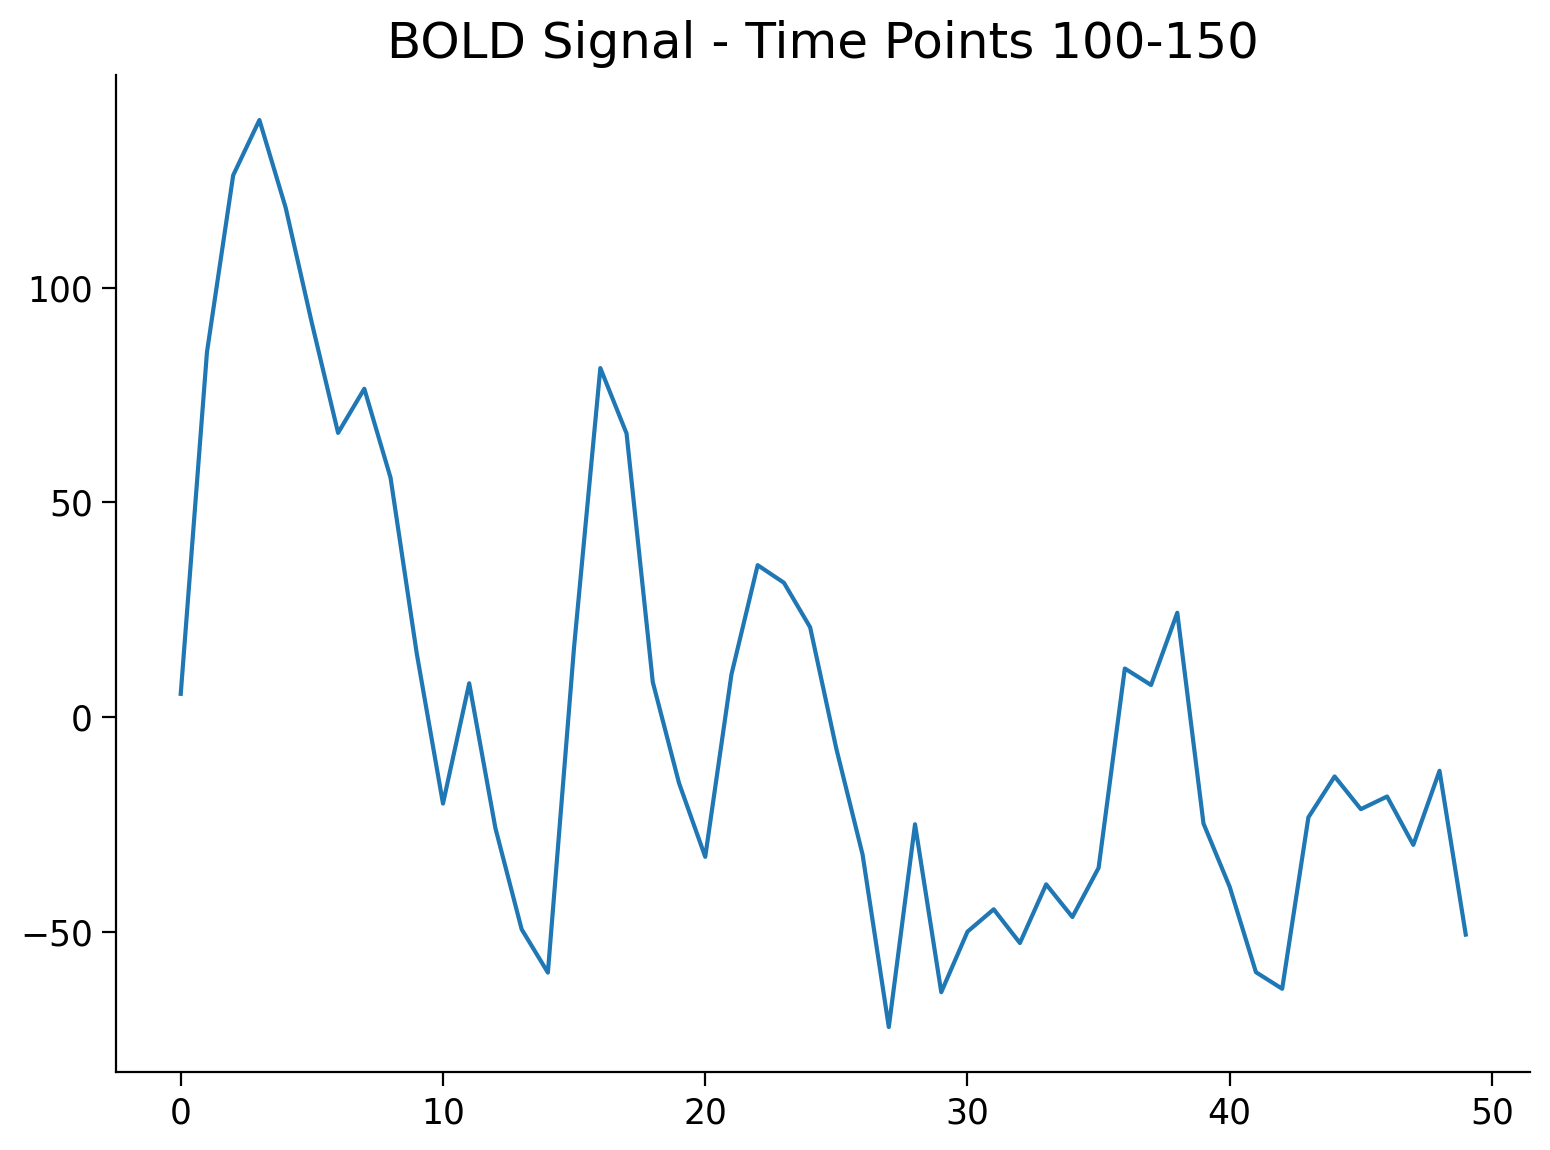

In [ ]:
plt.plot(bold_signals_participant1[0][100:150])
plt.title("BOLD Signal - Time Points 100-150")
plt.show()

# Compute FC

We have 100 participants, and 360 ROIs. Therefore, the FC array where we will collect the correlation, will have dimensions of 100 x 360 x 360.

Our data are stored in the dictionaries:

*   task_data_run0
*   task_data_run1

An easy way to compute the Pearson Correlation among the ROIs is to use the np.corrcoef.

In order to have similar variable name, we will name the correlation matrices as:

*   fc_run0
*   fc_run1

In [ ]:
N_SUBJECTS = 100 # participants
N_PARCELS = 360  # number of ROIs

# Initialize 3D arrays for FC matrices
fc_run0 = {}
fc_run1 = {}

for experiment in task_timepoints.keys():
    # Initialize the 3D array inside the dictionary for this specific experiment
    fc_run0[experiment] = np.zeros((N_SUBJECTS, N_PARCELS, N_PARCELS))
    fc_run1[experiment] = np.zeros((N_SUBJECTS, N_PARCELS, N_PARCELS))

    for i in range(N_SUBJECTS):
        bold_values_run0 = task_data_run0[experiment][i]
        bold_values_run1 = task_data_run1[experiment][i]

        # Store the 360x360 matrix for participant i
        fc_run0[experiment][i] = np.corrcoef(bold_values_run0)
        fc_run1[experiment][i] = np.corrcoef(bold_values_run1)



# Verify that FC have the expected dimensions (360 x 360)
for experiment in task_timepoints.keys():
    shape0 = fc_run0[experiment].shape
    shape1 = fc_run1[experiment].shape
    print(f"{experiment:10} | fc_run0 shape: {shape0} | fc_run1 shape: {shape1}")

MOTOR      | fc_run0 shape: (100, 360, 360) | fc_run1 shape: (100, 360, 360)
WM         | fc_run0 shape: (100, 360, 360) | fc_run1 shape: (100, 360, 360)
GAMBLING   | fc_run0 shape: (100, 360, 360) | fc_run1 shape: (100, 360, 360)
LANGUAGE   | fc_run0 shape: (100, 360, 360) | fc_run1 shape: (100, 360, 360)
SOCIAL     | fc_run0 shape: (100, 360, 360) | fc_run1 shape: (100, 360, 360)
RELATIONAL | fc_run0 shape: (100, 360, 360) | fc_run1 shape: (100, 360, 360)
EMOTION    | fc_run0 shape: (100, 360, 360) | fc_run1 shape: (100, 360, 360)


## Plot Functional Connectivity Matrix

Each FC dictionary (`fc_run0` and `fc_run1`) contains **7 keys** (one for each of the 7 tasks). Inside each key, there is a **3D NumPy array** with dimensions $100 \times 360 \times 360$.

This structure represents:
$$\text{Subjects (100)} \times \text{ROIs (360)} \times \text{ROIs (360)}$$

---

### Accessing a Specific FC Matrix

We can retrieve a specific participant's $360 \times 360$ Functional Connectivity matrix by indexing the dictionary as follows:

```python
# Retrieves the 360x360 FC matrix for the first participant (index 0)
# during the MOTOR task in the first run (Run 0)
fc_run0['MOTOR'][0]

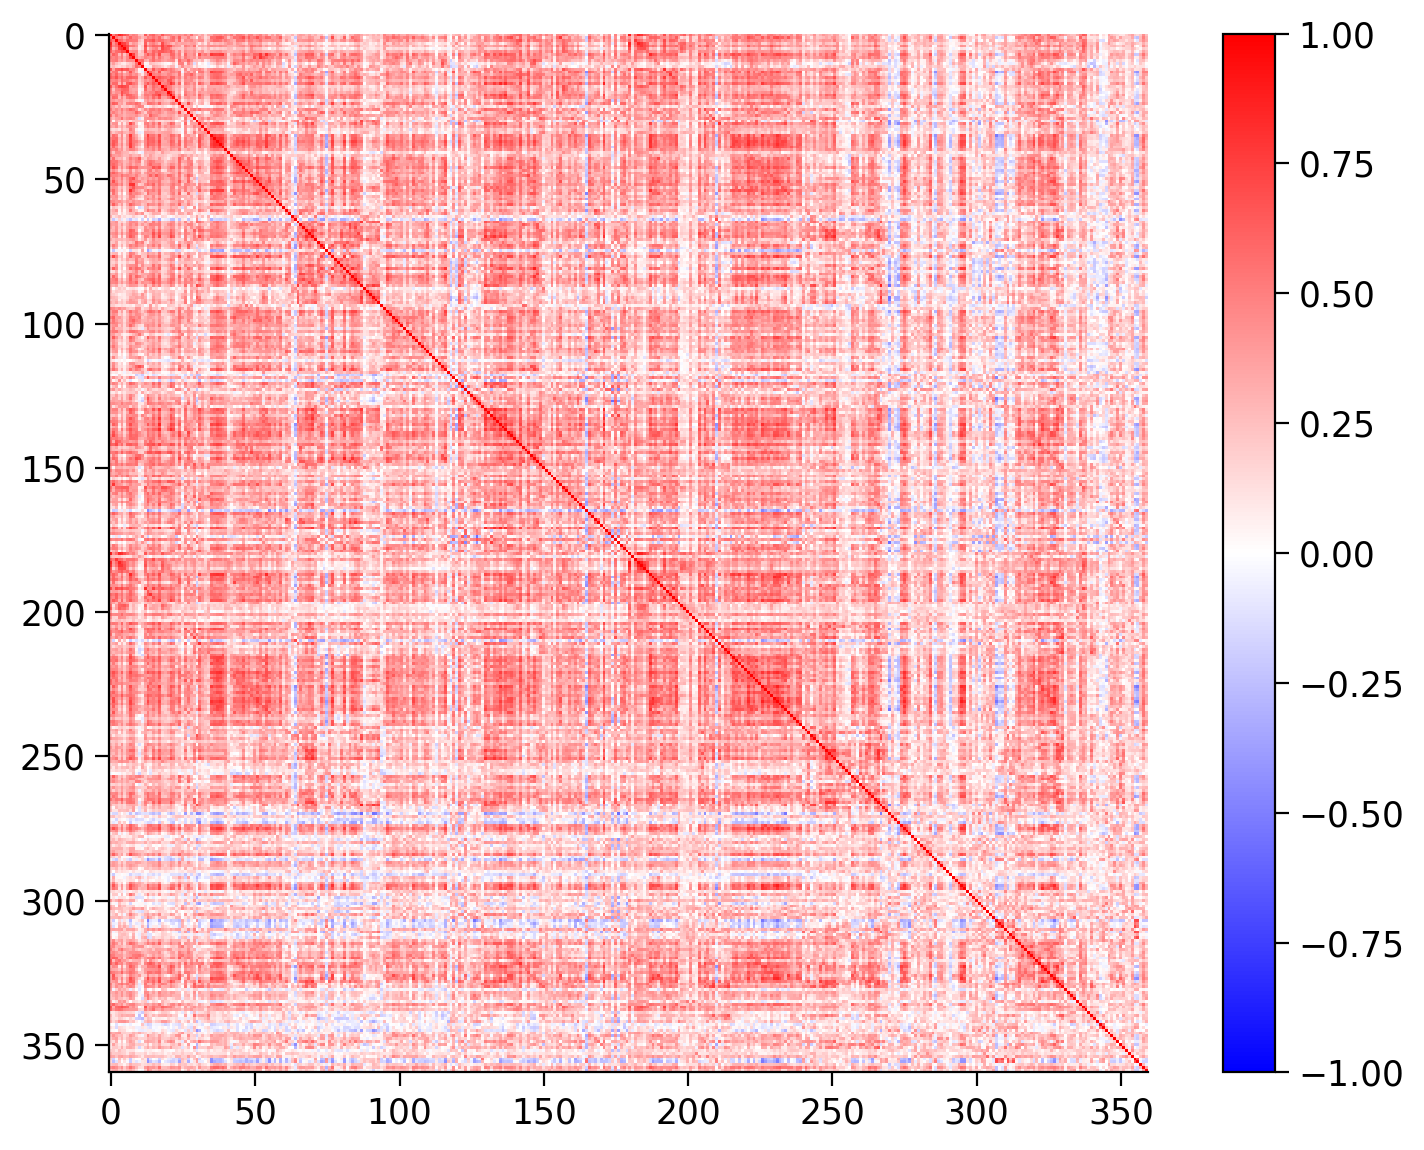

In [ ]:
select_participant = 20
select_experiment = 'MOTOR'


fc_selected_run0 = fc_run0[select_experiment][select_participant]
fc_selected_run1 = fc_run1[select_experiment][select_participant]

group_fc_run0 = fc_run0[select_experiment].mean(axis=0)
group_fc_run1 = fc_run1[select_experiment].mean(axis=0)

plt.figure()
plt.imshow(fc_selected_run0, interpolation="none", cmap="bwr", vmin=-1, vmax=1)
plt.colorbar()
plt.show()

# PCA (Trenyce)

Denoise with PCA and plot the eigenvalues to see the optimal number of principle components, previous studies (Chiem et al 2021 and the 2015 paper showed 100~200 as optimal). I think we are using a 90% variance explained threshold though.

In [ ]:
# Run PCA (code from W1D4 tut 3)
score, evectors, evals = pca(X)
# Plot the eigenvalues
plot_eigenvalues(evals, xlimit=True)

# ========== VARIANCE EXPLAINED ==============

def get_variance_explained(evals):
  """
  Calculates variance explained from the eigenvalues.

  Args:
    evals (numpy array of floats) : Vector of eigenvalues

  Returns:
    (numpy array of floats)       : Vector of variance explained

  """

  # Cumulatively sum the eigenvalues
  csum = np.cumsum(evals)

  # Normalize by the sum of eigenvalues
  variance_explained = csum/np.sum(evals)

  return variance_explained


# Calculate the variance explained
variance_explained = get_variance_explained(evals)

# Visualize
plot_variance_explained(variance_explained)

NameError: name 'pca' is not defined

# Reconstruct FC (MEMBER)

definte reconstruct_data function (taken directly from W1D4 tutorial 3) and apply in a for loop for each FC?

In [ ]:
def reconstruct_data(score, evectors, X_mean, K):
  """
  Reconstruct the data based on the top K components.

  Args:
    score (numpy array of floats)    : Score matrix
    evectors (numpy array of floats) : Matrix of eigenvectors
    X_mean (numpy array of floats)   : Vector corresponding to data mean
    K (scalar)                       : Number of components to include

  Returns:
    (numpy array of floats)          : Matrix of reconstructed data

  """
  # Reconstruct the data from the score and eigenvectors
  # Don't forget to add the mean!!
  X_reconstructed =  score @ evectors[0:K].T + X_mean

  return X_reconstructed


K = 784  # input data dimensions

# Reconstruct the data based on all components
X_mean = np.mean(X, 0)
X_reconstructed = reconstruct_data(score, evectors, X_mean, K)

# Plot the data and reconstruction
plot_MNIST_reconstruction(X, X_reconstructed, K)

NameError: name 'X' is not defined

# Similarity matrix (Sebastian)



# Differential Identifiability (Sebastian)

# Identification rate (yilin)

# Matching rate (yilin)

# Permutation test (MEMBER)